In [1]:
import pandas as pd

# Fixed the filename to include the (1) and the space
# Jump out of 'notebooks', then into 'data/raw/'
trips = pd.read_parquet("../data/raw/yellow_tripdata_2025-07.parquet", engine='pyarrow')
zones = pd.read_csv("../data/raw/taxi_zone_lookup (1).csv")

# Merge
df = trips.merge(zones, left_on='PULocationID', right_on='LocationID', how='left')

df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,LocationID,Borough,Zone,service_zone
0,1,2025-07-01 00:29:37,2025-07-01 00:45:30,1.0,7.30,1.0,N,138,74,1,...,6.94,1.0,54.79,0.0,1.75,0.00,138,Queens,LaGuardia Airport,Airports
1,1,2025-07-01 00:23:28,2025-07-01 01:07:44,1.0,17.70,2.0,N,132,142,1,...,0.00,1.0,80.75,2.5,1.75,0.00,132,Queens,JFK Airport,Airports
2,2,2025-07-01 00:53:50,2025-07-01 01:27:12,1.0,9.98,1.0,N,138,48,1,...,0.00,1.0,66.97,2.5,1.75,0.75,138,Queens,LaGuardia Airport,Airports
3,2,2025-07-01 00:58:49,2025-07-01 01:15:55,1.0,10.27,1.0,N,138,229,1,...,6.94,1.0,72.24,2.5,1.75,0.75,138,Queens,LaGuardia Airport,Airports
4,2,2025-07-01 00:09:22,2025-07-01 00:23:54,1.0,2.94,1.0,N,211,97,1,...,0.00,1.0,25.75,2.5,0.00,0.75,211,Manhattan,SoHo,Yellow Zone


In [2]:
# 1. Convert the pickup time to a real datetime format
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

# 2. Group by Zone and Hour to calculate "Demand"
# We use .size() to count the number of rows (trips) in each hour
hourly_demand = df.groupby(['PULocationID', pd.Grouper(key='tpep_pickup_datetime', freq='h')]).size().reset_index(name='trip_count')

# 3. Look at the result
print(hourly_demand.head())


   PULocationID tpep_pickup_datetime  trip_count
0             1  2025-07-01 05:00:00           2
1             1  2025-07-01 06:00:00           2
2             1  2025-07-01 09:00:00           2
3             1  2025-07-01 12:00:00           2
4             1  2025-07-01 14:00:00           1


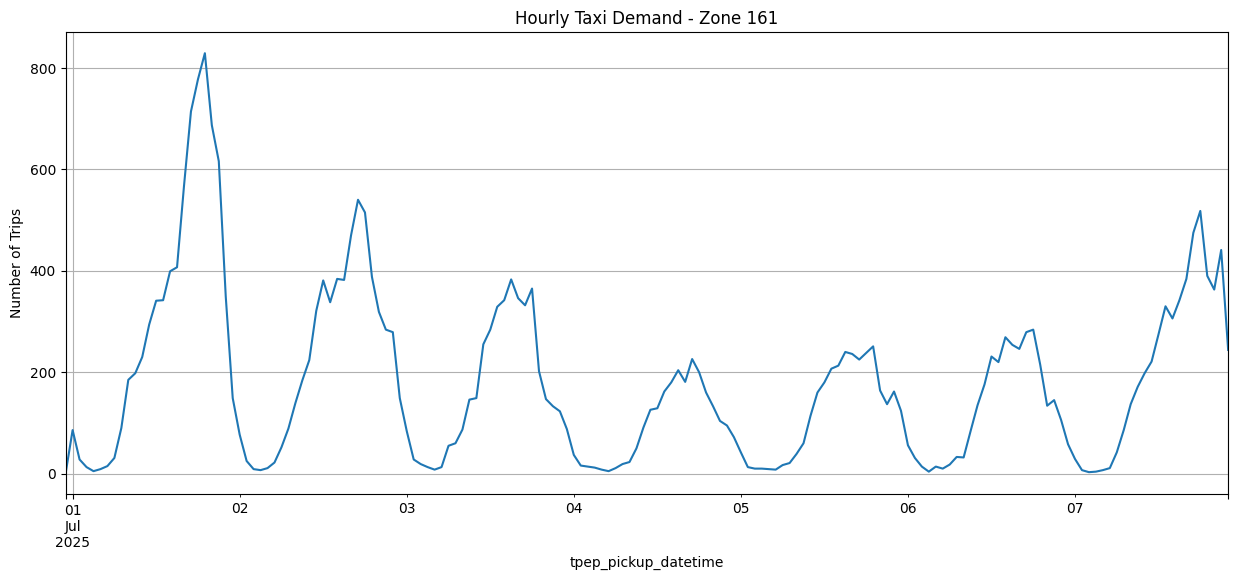

In [3]:
import matplotlib.pyplot as plt

# 1. Pick a high-demand zone (e.g., Zone 161 is Midtown Manhattan)
zone_id = 161
zone_data = hourly_demand[hourly_demand['PULocationID'] == zone_id].copy()

# 2. Set the timestamp as the index
zone_data = zone_data.set_index('tpep_pickup_datetime')

# 3. Fill missing hours with 0 (Resampling)
# This creates a row for EVERY hour, even if trip_count was NaN
zone_data = zone_data.resample('h').asfreq().fillna(0)

# 4. Plot the first 7 days (168 hours)
plt.figure(figsize=(15, 6))
zone_data['trip_count'].head(168).plot(title=f"Hourly Taxi Demand - Zone {zone_id}")
plt.ylabel("Number of Trips")
plt.grid(True)
plt.show()

In [4]:
# --- FEATURE ENGINEERING ---
import numpy as np
print("Extracting Time-Series Features...")

# Adding simple time-based features
zone_data['hour_of_day'] = zone_data.index.hour
zone_data['day_of_week'] = zone_data.index.dayofweek
zone_data['is_weekend'] = np.where(zone_data.index.dayofweek >= 5, 1, 0)


# Creating Lag Features (What was the demand exactly 24 hours ago? 168 hours ago?)
zone_data['demand_24h_ago'] = zone_data['trip_count'].shift(24)
zone_data['demand_168h_ago'] = zone_data['trip_count'].shift(168)

# Drop the rows that now have NaN because of the historical shift (the first 7 days)
zone_data = zone_data.dropna()

print(zone_data.head())


Extracting Time-Series Features...
                      PULocationID  trip_count  hour_of_day  day_of_week  \
tpep_pickup_datetime                                                       
2025-07-07 23:00:00            161         125           23            0   
2025-07-08 00:00:00            161          52            0            1   
2025-07-08 01:00:00            161          26            1            1   
2025-07-08 02:00:00            161           9            2            1   
2025-07-08 03:00:00            161           5            3            1   

                      is_weekend  demand_24h_ago  demand_168h_ago  
tpep_pickup_datetime                                               
2025-07-07 23:00:00            0            58.0              1.0  
2025-07-08 00:00:00            0            29.0             86.0  
2025-07-08 01:00:00            0             7.0             28.0  
2025-07-08 02:00:00            0             3.0             13.0  
2025-07-08 03:00:00     

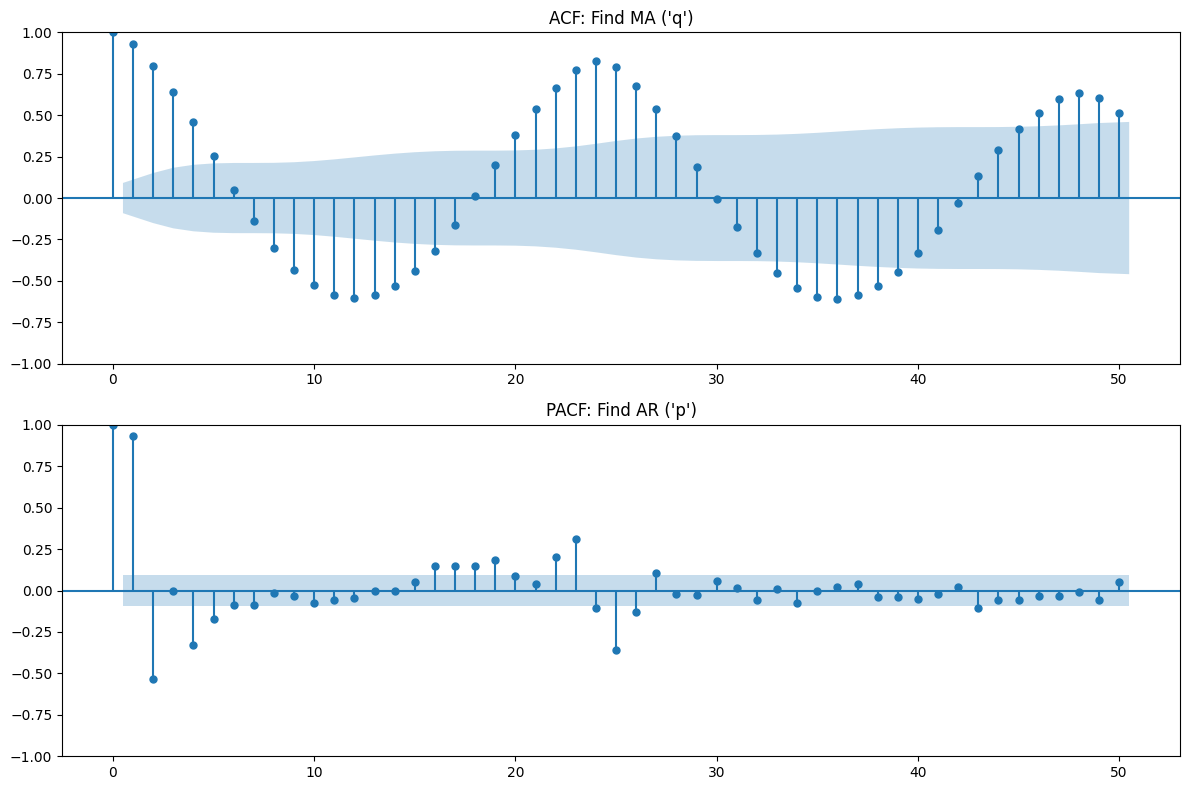

In [5]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# --- ADD THIS LINE BACK ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# 1. ACF Chart
train_size = int(len(zone_data) * 0.8)
y_train = zone_data['trip_count'].iloc[:train_size]

plot_acf(y_train, ax=ax1, lags=50, title="ACF: Find MA ('q')")

# 2. PACF Chart
plot_pacf(y_train, ax=ax2, lags=50, title="PACF: Find AR ('p')")

plt.tight_layout()
plt.show()

In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller  # <--- Imported for ADF Test
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt
# Define ALL our extra features, including the lags!
exog_vars = ['hour_of_day', 'day_of_week', 'is_weekend', 'demand_24h_ago', 'demand_168h_ago']
# 1. Train/Test Split
test_hours = 168
train_size = len(zone_data) - test_hours
train, test = zone_data.iloc[:train_size], zone_data.iloc[train_size:]
# Separate the target (y) and the exogenous features (X)
y_train = train['trip_count']
X_train = train[exog_vars]
y_test = test['trip_count']
X_test = test[exog_vars]
# --- NEW: INSERT THE ADF TEST HERE ---
print("Running ADF Test to find mathematical differencing order (d)...")
d = 0
series_diff = y_train.copy()
while d <= 2:
    if series_diff.std() == 0: break
    pval = adfuller(series_diff.dropna(), autolag='AIC')[1]
    if pval < 0.05: break # It is stationary!
    series_diff = series_diff.diff().dropna()
    d += 1
print(f"ADF Test Complete. Optimal 'd' value is: {d}")

# 2. Train the Model using our new automatically calculated 'd'
print("Training SARIMAX with Exogenous Variables...")

sari_model = SARIMAX(y_train, exog=X_train, order=(1, d, 1), seasonal_order=(1, d, 1, 24), enforce_stationarity=False)
sari_fit = sari_model.fit(disp=False)
# 3. Forecast the Hidden Test Period
predictions = sari_fit.forecast(steps=test_hours, exog=X_test)
predictions = predictions.clip(lower=0) # Prevent impossible negative taxi trips , if prediction >0 then all good
# 4. Evaluate Accuracy Metrics
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
wmape = np.sum(np.abs(y_test - predictions)) / np.sum(y_test)
print(f"\n --- OFFICIAL EVALUATION METRICS --- ")
print(f"Mean Absolute Error (MAE): {mae:.2f} trips")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} trips") #2f means random number like 19.2312421 will be made professional
print(f"Weighted MAPE: {wmape * 100:.2f}%\n")


Running ADF Test to find mathematical differencing order (d)...
ADF Test Complete. Optimal 'd' value is: 1
Training SARIMAX with Exogenous Variables...


c:\Users\yadav\OneDrive\Desktop\taxiCloneNew\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



 --- OFFICIAL EVALUATION METRICS --- 
Mean Absolute Error (MAE): 47.85 trips
Root Mean Squared Error (RMSE): 62.19 trips
Weighted MAPE: 19.31%



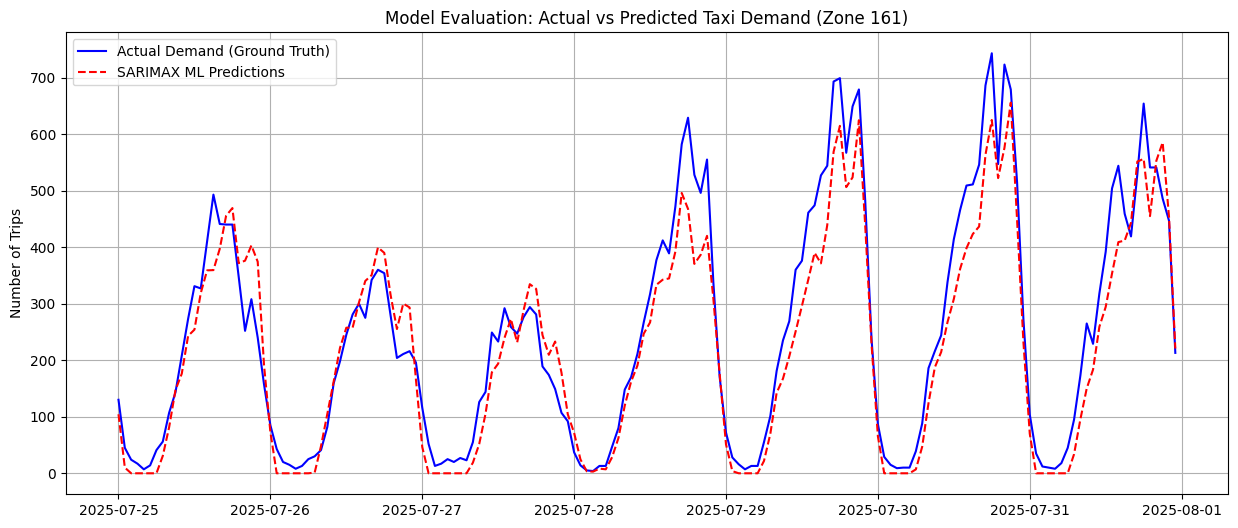

In [7]:
# --- PLOTTING THE RESULTS ---
plt.figure(figsize=(15, 6))

# Plot actual real-world test data
plt.plot(test.index, test['trip_count'], label='Actual Demand (Ground Truth)', color='blue')
# Plot our model's predictions
plt.plot(test.index, predictions, label='SARIMAX ML Predictions', color='red', linestyle='dashed')

plt.title(f"Model Evaluation: Actual vs Predicted Taxi Demand (Zone {zone_id})")
plt.ylabel("Number of Trips")
plt.legend()
plt.grid(True)
plt.show()
